In [1]:
print("Speech Analysis Module Initialized")

Speech Analysis Module Initialized


In [2]:
!pip install librosa soundfile

In [3]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


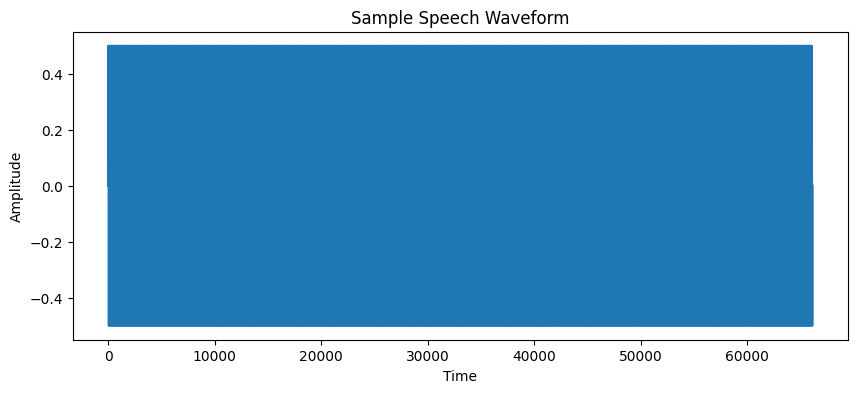

In [4]:
duration = 3
sr = 22050

t = np.linspace(0, duration, int(sr * duration))

audio = 0.5 * np.sin(2 * np.pi * 220 * t)

plt.figure(figsize=(10,4))
plt.plot(audio)
plt.title("Sample Speech Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

MFCC Shape: (13, 130)


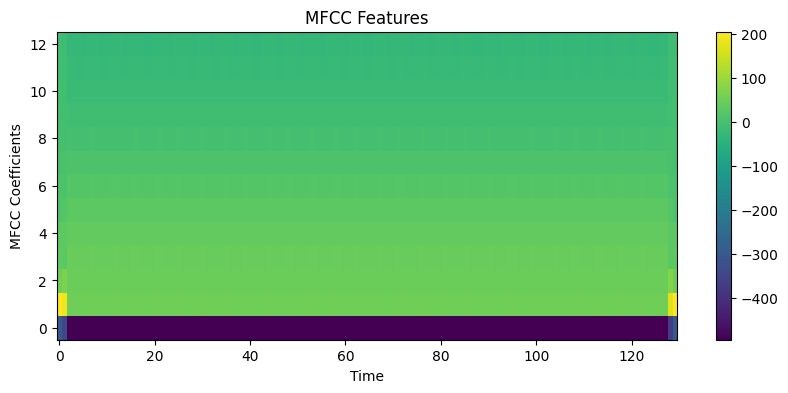

In [5]:
mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)

print("MFCC Shape:", mfccs.shape)

plt.figure(figsize=(10,4))
plt.imshow(mfccs, aspect='auto', origin='lower')
plt.colorbar()
plt.title("MFCC Features")
plt.xlabel("Time")
plt.ylabel("MFCC Coefficients")
plt.show()

In [6]:
!pip install kaggle

In [7]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle Connected Successfully")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle Connected Successfully


In [8]:
!kaggle datasets list -s "dementia"

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [9]:
!kaggle datasets list -s "speech audio"

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [10]:
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio

Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
100% 429M/429M [00:03<00:00, 117MB/s] 



In [11]:
!unzip ravdess-emotional-speech-audio.zip -d speech_data

Archive:  ravdess-emotional-speech-audio.zip
  inflating: speech_data/Actor_01/03-01-01-01-01-01-01.wav  
  inflating: speech_data/Actor_01/03-01-01-01-01-02-01.wav  
  inflating: speech_data/Actor_01/03-01-01-01-02-01-01.wav  
  inflating: speech_data/Actor_01/03-01-01-01-02-02-01.wav  
  inflating: speech_data/Actor_01/03-01-02-01-01-01-01.wav  
  inflating: speech_data/Actor_01/03-01-02-01-01-02-01.wav  
  inflating: speech_data/Actor_01/03-01-02-01-02-01-01.wav  
  inflating: speech_data/Actor_01/03-01-02-01-02-02-01.wav  
  inflating: speech_data/Actor_01/03-01-02-02-01-01-01.wav  
  inflating: speech_data/Actor_01/03-01-02-02-01-02-01.wav  
  inflating: speech_data/Actor_01/03-01-02-02-02-01-01.wav  
  inflating: speech_data/Actor_01/03-01-02-02-02-02-01.wav  
  inflating: speech_data/Actor_01/03-01-03-01-01-01-01.wav  
  inflating: speech_data/Actor_01/03-01-03-01-01-02-01.wav  
  inflating: speech_data/Actor_01/03-01-03-01-02-01-01.wav  
  inflating: speech_data/Actor_01/03-01-

In [12]:
import os

count = 0

for root, dirs, files in os.walk("speech_data"):
    for file in files:
        if file.endswith(".wav"):
            count += 1

print("Total Audio Files:", count)

Total Audio Files: 2880


In [13]:
import os
import librosa
import numpy as np

features = []
labels = []

audio_count = 0

for root, dirs, files in os.walk("speech_data"):
    for file in files:
        if file.endswith(".wav"):

            file_path = os.path.join(root, file)

            signal, sr = librosa.load(file_path, sr=22050)

            mfcc = librosa.feature.mfcc(
                y=signal,
                sr=sr,
                n_mfcc=13
            )

            mfcc_mean = np.mean(mfcc.T, axis=0)

            features.append(mfcc_mean)

            emotion = int(file.split("-")[2])

            labels.append(emotion)

            audio_count += 1

            if audio_count >= 500:
                break

    if audio_count >= 500:
        break

print("Features Extracted:", len(features))
print("Labels Created:", len(labels))

Features Extracted: 500
Labels Created: 500


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Speech AI Model Accuracy:", round(accuracy*100, 2), "%")

Speech AI Model Accuracy: 57.0 %


In [15]:
import joblib

joblib.dump(model, "speech_ai_model.pkl")

print("Speech Model Saved Successfully")

Speech Model Saved Successfully


In [16]:
import os

found = False

for root, dirs, files in os.walk("speech_data"):
    for file in files:
        if file.endswith(".wav"):
            sample_file = os.path.join(root, file)
            print("Sample Audio File:")
            print(sample_file)
            found = True
            break

    if found:
        break

Sample Audio File:
speech_data/Actor_07/03-01-06-02-02-02-07.wav


In [17]:
import joblib
import librosa
import numpy as np

model = joblib.load("speech_ai_model.pkl")

audio_file = "speech_data/Actor_03/03-01-03-02-02-02-03.wav"

signal, sr = librosa.load(audio_file, sr=22050)

mfcc = librosa.feature.mfcc(
    y=signal,
    sr=sr,
    n_mfcc=13
)

mfcc_mean = np.mean(mfcc.T, axis=0)

prediction = model.predict([mfcc_mean])

print("Predicted Emotion Class:", prediction[0])

Predicted Emotion Class: 6


In [18]:
import pandas as pd

emotion_names = {
    1: "Neutral",
    2: "Calm",
    3: "Happy",
    4: "Sad",
    5: "Angry",
    6: "Fearful",
    7: "Disgust",
    8: "Surprised"
}

predicted_class = int(prediction[0])

print("Predicted Emotion:", emotion_names.get(predicted_class, "Unknown"))

Predicted Emotion: Fearful


In [19]:
emotion_names = {
    1: "Neutral",
    2: "Calm",
    3: "Happy",
    4: "Sad",
    5: "Angry",
    6: "Fearful",
    7: "Disgust",
    8: "Surprised"
}

emotion_count = {}

for label in labels:
    emotion_name = emotion_names.get(label, "Unknown")

    if emotion_name not in emotion_count:
        emotion_count[emotion_name] = 0

    emotion_count[emotion_name] += 1

print("Emotion Distribution")
print(emotion_count)

Emotion Distribution
{'Fearful': 69, 'Happy': 68, 'Calm': 66, 'Angry': 68, 'Neutral': 33, 'Disgust': 65, 'Surprised': 65, 'Sad': 66}


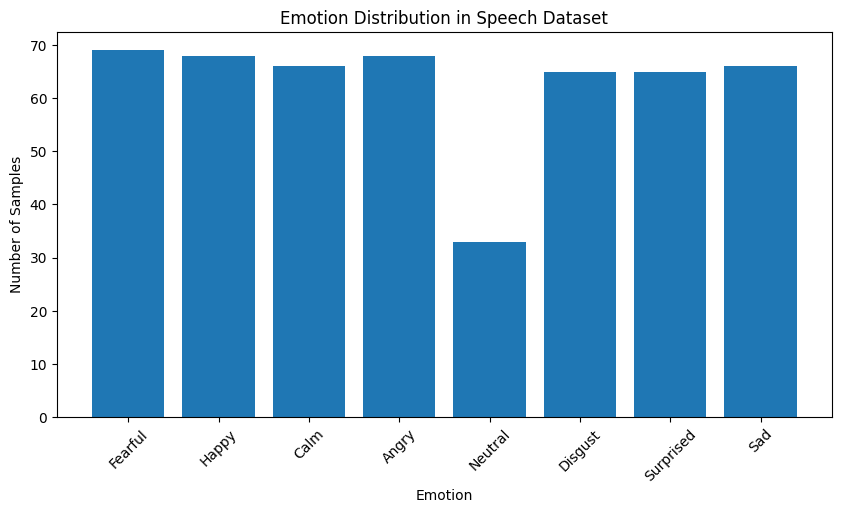

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(emotion_count.keys(), emotion_count.values())

plt.title("Emotion Distribution in Speech Dataset")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")

plt.xticks(rotation=45)

plt.show()